Task 2:

A real estate analyst wants to predict the median value of houses in different neighborhoods based on various property and neighborhood features. You are tasked with building a Multiple Linear Regression model that can predict housing prices using numerical predictors.

Dataset features (example):
    o	RM → average number of rooms per dwelling
    o	LSTAT → % lower status of the population
    o	PTRATIO → pupil-teacher ratio by town
    o	INDUS → proportion of non-retail business acres per town
    o	NOX → nitric oxides concentration
    o	AGE → proportion of owner occupied units built before 1940
    o	MEDV → median value of owner-occupied homes (target variable)


1: Load Data

In [1]:
import pandas as pd

df = pd.read_csv("Boston.csv")  # download from Kaggle

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  BIAS_COL  
0  396.90   4.98  24.0         1  
1  396.90   9.14  21.6         1  
2  392.83   4.03  34.7         1  
3  394.63   2.94  33.4         1  
4  396.90   5.33  36.2         1  


2 Explore Data

2.1 Check Missing Values

In [2]:
print(df.isnull().sum())

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
BIAS_COL    0
dtype: int64


2.2 Basic Statistics

In [3]:
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

2.3 Correlation Heatmap

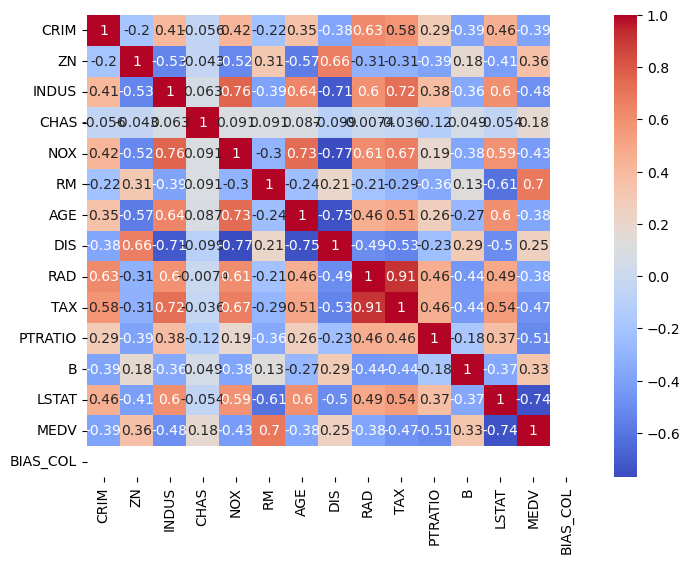

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

3 Data Preparation

3.1 Select Features & Target

In [5]:
features = ["RM", "LSTAT", "PTRATIO", "INDUS", "NOX", "AGE"]
X = df[features]
y = df["MEDV"]

3.2 Handle missing values

In [6]:
df = df.fillna(df.mean())

3.3 Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4 Build Model
MEDV=5+4.2(RM)−0.8(LSTAT)−1.2(NOX)+...

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

5 Evaluate Model

5.1 Predictions

In [9]:
y_pred = model.predict(X_test)

5.2 Mean Squared Error (MSE)

In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 26.782523432699964


5.3 R² Score

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6347860115964865


6 Interpretation

6.1 Coefficients

In [12]:
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coeff_df)

   Feature  Coefficient
0       RM     4.776817
1    LSTAT    -0.593496
2  PTRATIO    -0.948690
3    INDUS     0.065783
4      NOX    -8.650123
5      AGE     0.032273


6.2 Actual vs Predicted Plot

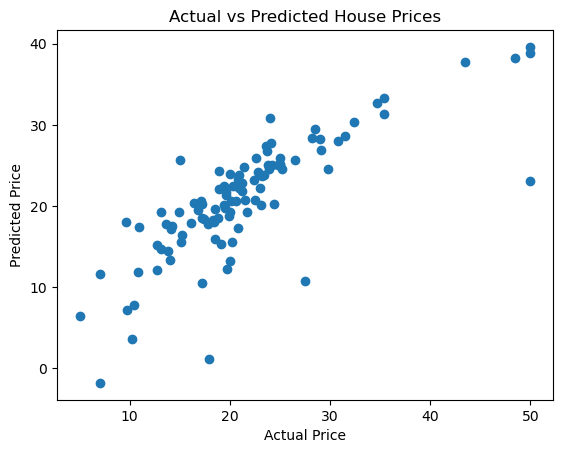

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()